# MITGCM Time Scale dependency Analysis 

**Purpose**: Code for exploring the relationship between decorrelation time scales and duration of record and spectral slope. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [10]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from autocorr import segment_time_series, windowed_decorrelation_scale
from spectra import spectrum1D_frequency, spectral_slope
from lsf import unweighted_lsf, compute_amp_phase, detrend
from plotScaleAnalysis import month_fmt

Set data analysis parameters

In [3]:
# Set processing parameters
option_plot          = 0      # Specifies if supplementary plots are plotted
option_var           = 'density'  # Specifies which variable will analyzed. Options include: temp, sal, density, u_along, v_cross

# Set time and space parameters
dt            = 1*(60)*(60)                   # Specifies the sampling interval in seconds (e.g., 1 hour = 3600 seconds)

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'

# Set plotting parameters 
fontsize = 16

# Set font and fontsize
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
if (option_var == 'temp') | (option_var == 'sal') | (option_var == 'density'):
    filename = PATH + "mitgcm_intermediate_data_TSD_hrly_ts_profiles.nc"
elif (option_var == 'u_along') | (option_var == 'v_cross'):
    filename = PATH + "mitgcm_intermediate_data_vel_hrly_ts_profiles.nc"
nc = Dataset(filename, 'r')

# Extract data variables
depth = nc.variables['depth'][:]
lon   = nc.variables['LON'][:]
lat   = nc.variables['LAT'][:]
time  =  num2date(nc.variables['time'][:], nc.variables['time'].units)

if option_var == 'temp':
    data = nc.variables['CTemp'][:]
elif option_var == 'sal':
    data = nc.variables['ASal'][:]
elif option_var == 'density':
    data = nc.variables['SIG'][:]
elif option_var == 'u_along':
    data = nc.variables['u_along'][:]
elif option_var == 'v_cross':
    data = nc.variables['v_cross'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Load in the data for the decorrelation scale as a function of scale for set spectral slopes

In [5]:
#-------------------------------------------------------#
# Simulated Data
#-------------------------------------------------------#
PATH_sim = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
ROOT_sim = "/data/synthetic"
filename_sim    = PATH_sim + ROOT_sim + "/decorrelation_window_size_fit.npz"

# Load data 
ds_sim   = np.load(filename_sim, allow_pickle=True)

# Extract data variables
Lt_av          = ds_sim['Lt_av']    # Units: days
Lt_stdm        = ds_sim['Lt_stdm']  # Units: days
Lt_fit         = ds_sim['Lt_fit']   # Units: days         
scales         = ds_sim['scales']   # Units: months
alphas         = ds_sim['alpha']

Plot profile time series and time averaged profile

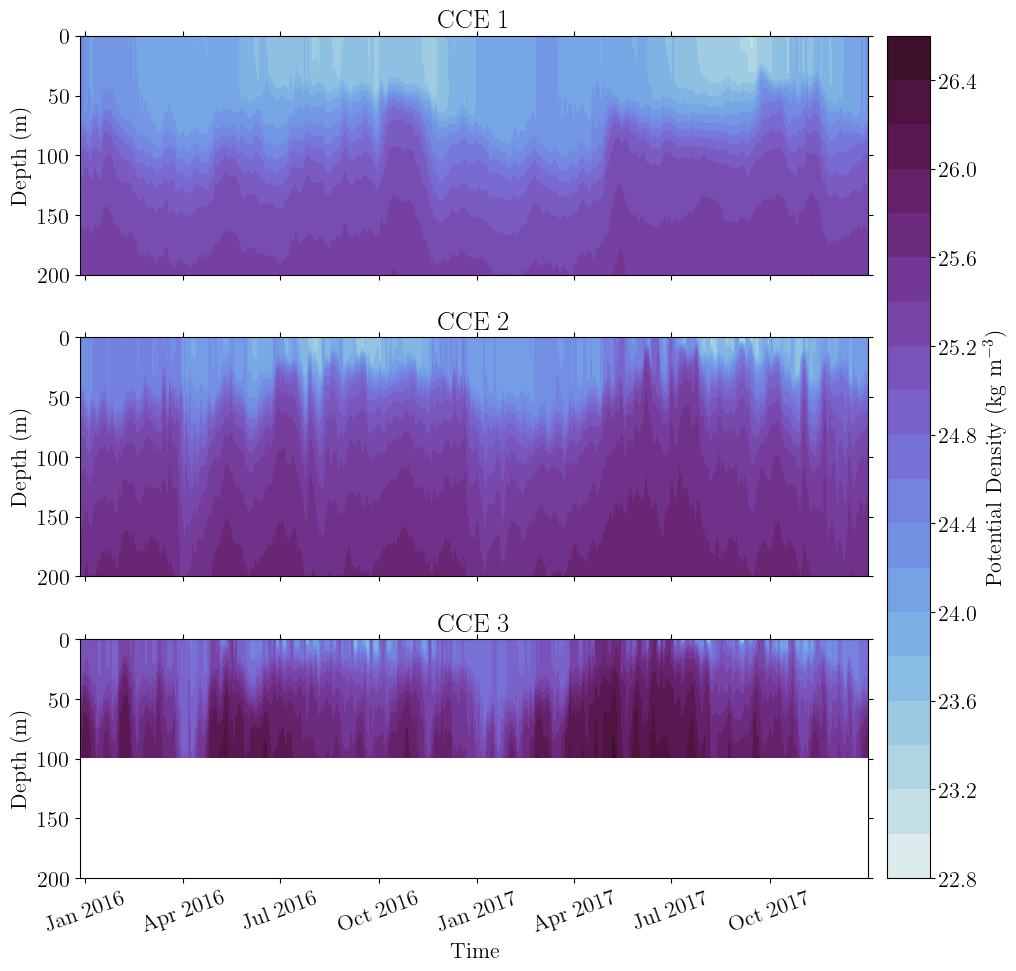

In [6]:
# Set the fontsize
plt.rcParams.update({'font.size': fontsize})

# Set plotting parameters
if option_var == 'temp':
    label = r'Conservative Temperature (deg C)'
    cmap = cmo.thermal
elif option_var == 'sal':
    label = r'Absolute Salinity (g/kg)'
    cmap = cmo.haline
elif option_var == 'density': 
    label = r'Potential Density (kg m$^{-3}$)'
    cmap = cmo.dense
elif option_var == 'u_along': 
    label = r'Along-shelf Velocity (ms$^{-1}$)'
    cmap = cmo.balance
elif option_var == 'v_cross': 
    label = r'Cross-shelf Velocity (ms$^{-1}$)'
    cmap = cmo.balance

# Create figure
fig,axes = plt.subplots(3,1,figsize=(12, 10))
ax1,ax2,ax3 =  axes.flatten()

# Loop through axes
for i, ax in enumerate(axes):

    # Plot temperature
    if (option_var == 'u_along') | (option_var == 'v_cross'): 
        cf = ax.contourf(time_dt,abs(depth),data[i,:,:].T, levels=20, cmap=cmap, vmin=-1.2, vmax=1.2)
    else:
        cf = ax.contourf(time_dt,abs(depth),data[i,:,:].T, levels=20, cmap=cmap)

    # Set axis attributes
    ax.set_title(f"CCE {i+1}")
    ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.set_ylabel("Depth (m)")
    ax.tick_params(top=True, bottom=True, left=True, right=True,
                   direction='out', length=3.5)
    plt.setp(ax.get_xticklabels(), rotation=20)
    if (i == 0) | (i == 1):
        ax.set_xticklabels([])
    if i == 2:
        ax.set_xlabel("Time")

# Adjust layout before adding colorbar
plt.tight_layout()
fig.subplots_adjust(right=0.87)  # Make space on the right side

# Add shared colorbar
cbar = fig.colorbar(cf, ax=axes, location='right', pad=0.02)
cbar.set_label(label)

# Show figure
plt.show()

Extract data at depths greater than 200 meters

In [7]:
# Set depth range and find indices for depth levels 
depth_upper_lim = -210
idx_depth = depth >= depth_upper_lim

# Subset data to depth levels of interest
depth_upper = depth[idx_depth]
data_upper  = data[:,:, idx_depth]

# Set dimensions for the data array 
n_site = data_upper.shape[0]
n_time = data_upper.shape[1]
n_depth = data_upper.shape[2]

### **Section 1**: Compute the decorrelation scale as a function of record length 

In [ ]:
# Window sizes (number of samples)
n_hours    = data.shape[1]
min_window = 300
max_divisor = n_hours // min_window
divisors    = np.arange(2, max_divisor + 1)
window_sizes = np.unique(n_hours // divisors)
window_sizes = window_sizes[window_sizes >= min_window][::-1]
n_windows = len(window_sizes)                                 

# Set parameters
w1, w2 = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]        # Specifies the radian Frequency for annual and semi-annual cycles. Units: rad/sec
overlap   = 0.5                                              # Specifies the fractional overlap between segments (e.g., 0.75 for 75% overlap)

# Extract  each CCE site
data_cce1 = data_upper[0, :, :]
data_cce2 = data_upper[1, :, :]
data_cce3 = data_upper[2, :, :]

# Compute the elapsed time from beginning of segmented time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

# Initialize arrays to store decorrelation scales in units of days
Lt_cce1_av_days = np.zeros((n_depth,n_windows))
Lt_cce2_av_days = np.zeros((n_depth,n_windows))
Lt_cce3_av_days = np.zeros((n_depth,n_windows))
Lt_cce1_stdm_days = np.zeros((n_depth,n_windows))
Lt_cce2_stdm_days = np.zeros((n_depth,n_windows))
Lt_cce3_stdm_days = np.zeros((n_depth,n_windows))

#--- CCE 1 and 2 ---# 

# Loop through depths 
for idepth in range(n_depth):

    # Set progress bar
    progress = (idepth+1) / (n_depth)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    if option_var in ('temp', 'sal', 'density'):

        # Remove the annual and semi-annual cycles
        hfit_cce1, *_ = unweighted_lsf(data_cce1[:, idepth], time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
        hfit_cce2, *_ = unweighted_lsf(data_cce2[:, idepth], time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
        data_cce1_rm = data_cce1[:, idepth] - hfit_cce1
        data_cce2_rm = data_cce2[:, idepth] - hfit_cce2

    else: 

        # Do NOT remove the annual and semi-annual cycles
        data_cce1_rm = data_cce1[:, idepth] 
        data_cce2_rm = data_cce2[:, idepth] 

    # Preform scale analysis
    scales_cce1, Lt_cce1_av, Lt_cce1_stdm, window_cce1_dict = windowed_decorrelation_scale(data_cce1_rm, time_elapsed, dt, 
                                                                            scales=window_sizes, norm=False, overlap=overlap, 
                                                                            return_windows=True, valid_frac=0.8, detrend_option=True)
    scales_cce2, Lt_cce2_av, Lt_cce2_stdm, window_cce2_dict = windowed_decorrelation_scale(data_cce2_rm, time_elapsed, dt, 
                                                                            scales=window_sizes, norm=False, overlap=overlap, 
                                                                            return_windows=True, valid_frac=0.8, detrend_option=True)
    
    # Convert window size to units of days
    window_sizes_days = window_sizes / 24 

    # Convert decorrelation scales to units of days
    Lt_cce1_av_days[idepth, :] = Lt_cce1_av * (1/60) * (1/60) * (1/24)
    Lt_cce2_av_days[idepth, :] = Lt_cce2_av * (1/60) * (1/60) * (1/24)

    Lt_cce1_stdm_days[idepth, :] = Lt_cce1_stdm * (1/60) * (1/60) * (1/24)
    Lt_cce2_stdm_days[idepth, :] = Lt_cce2_stdm * (1/60) * (1/60) * (1/24)

# Set the number of depth levels greater than -100 m 
n_depth_cce3 = np.sum(depth_upper >= -100)

#--- CCE 3 ---# 

# Loop through depths 
for idepth in range(n_depth_cce3):

    # Set progress bar
    progress = (idepth+1) / (n_depth_cce3)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    if option_var in ('temp', 'sal', 'density'):

        # Remove the annual and semi-annual cycles
        hfit_cce3, *_ = unweighted_lsf(data_cce3[:, idepth], time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
        data_cce3_rm = data_cce3[:, idepth] - hfit_cce3

    else: 

        # Do NOT remove the annual and semi-annual cycles
        data_cce3_rm = data_cce3[:, idepth] 

    # Preform scale analysis
    scales_cce3, Lt_cce3_av, Lt_cce3_stdm, window_cce3_dict = windowed_decorrelation_scale(data_cce3_rm, time_elapsed, dt, 
                                                                            scales=window_sizes, norm=False, overlap=overlap, 
                                                                            return_windows=True, valid_frac=0.8, detrend_option=True)

    # Convert window size to units of days
    window_sizes_days = window_sizes / 24 

    # Convert decorrelation scales to units of days
    Lt_cce3_av_days[idepth, :] = Lt_cce3_av * (1/60) * (1/60) * (1/24)

    Lt_cce3_stdm_days[idepth, :] = Lt_cce3_stdm * (1/60) * (1/60) * (1/24)

# Ensemble average decorrelation scales across depth 
Lt_cce1_av_ensemble = np.nanmean(Lt_cce1_av_days, axis=0)
Lt_cce2_av_ensemble = np.nanmean(Lt_cce2_av_days, axis=0)
Lt_cce3_av_ensemble = np.nanmean(Lt_cce3_av_days, axis=0)

Lt_cce1_stdm_ensemble = np.nanmean(Lt_cce1_stdm_days, axis=0)
Lt_cce2_stdm_ensemble = np.nanmean(Lt_cce2_stdm_days, axis=0)
Lt_cce3_stdm_ensemble = np.nanmean(Lt_cce3_stdm_days, axis=0)

Progress: 100.0%

In [108]:
# Set zeros to NaN for CCE3
Lt_cce3_av_days = np.where(Lt_cce3_av_days == 0, np.nan, Lt_cce3_av_days)

Lt_cce1_av_ensemble = np.nanmedian(Lt_cce1_av_days, axis=0)
Lt_cce2_av_ensemble = np.nanmedian(Lt_cce2_av_days, axis=0)
Lt_cce3_av_ensemble = np.nanmedian(Lt_cce3_av_days, axis=0)

Lt_cce1_stdm_ensemble = np.nanmedian(Lt_cce1_stdm_days, axis=0)
Lt_cce2_stdm_ensemble = np.nanmedian(Lt_cce2_stdm_days, axis=0)
Lt_cce3_stdm_ensemble = np.nanmedian(Lt_cce3_stdm_days, axis=0)

Compute the ensemble mean over the top 50 meters of the ocean 

In [69]:
# Find the depth indices for the top 50 meters 
depth_lim = -25
idx_depth_m = depth_upper >= depth_lim

# Compute the average decorrelation scale across the top 50 meters for each window size
Lt_cce1_av_50m = np.nanmean(Lt_cce1_av_days[idx_depth_m, :], axis=0)
Lt_cce2_av_50m = np.nanmean(Lt_cce2_av_days[idx_depth_m, :], axis=0)
Lt_cce3_av_50m = np.nanmean(Lt_cce3_av_days[idx_depth_m, :], axis=0)

Lt_cce1_stdm_50m = np.nanmean(Lt_cce1_stdm_days[idx_depth_m, :], axis=0)
Lt_cce2_stdm_50m = np.nanmean(Lt_cce2_stdm_days[idx_depth_m, :], axis=0)
Lt_cce3_stdm_50m = np.nanmean(Lt_cce3_stdm_days[idx_depth_m, :], axis=0)

### **Section 2**: Compute the power spectrum and its spectral slope 

In [15]:
# Set dimnesion by segmenting data at a single depth and looking at the lengths
overlap = 0.5                                                                            # Specifies the fractional overlap between segments (e.g., 0.75 for 75% overlap)
segment_years = 1                                                                        # Specifies the length of each segment in years
segments       = segment_time_series(time, data_upper[0,:,0], segment_years=segment_years, overlap=overlap)
nseg,ntime_seg     = np.shape(segments)[0], np.shape(segments)[2]

# Set parameters
w1, w2 = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]     # Specifies the radian Frequency for annual and semi-annual cycles. Units: rad/sec
M = 10                                                       # Specifies number of windows to divide the data into for the Welch method
p = ntime_seg // M                                               # Specifies window length, i.e., number of data points in each segment
nfft = (p // 2 + 1) if (p % 2 == 0) else ((p - 1) // 2)      # Specifies number of positive frequency bins in the resulting power spectrum
units = 'Hz'                                                 # Specifies the units of the frequency vector 
estimator = 'biased'                                        # Specifies the type of autocorrelation estimator ('biased' or 'unbiased')
option_plot = False

# Define frequency range for slope fitting 
fmin_sub = 3*10**(-2) 
fmax_sub = 8*10**(-1) 
fmin_sup = 1 
fmax_sup = 12
    
# Compute the elapsed time from beginning of segmented time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

# Initialize arrays
S_seg               = np.zeros((n_site,n_depth,nfft))
CI_seg              = np.zeros((n_site,n_depth,nfft,2))
S_seg_slope_sub     = np.zeros((n_site,n_depth))
S_seg_slope_sub_unc = np.zeros((n_site,n_depth))
S_seg_slope_sup     = np.zeros((n_site,n_depth))
S_seg_slope_sup_unc = np.zeros((n_site,n_depth))
S_seg_slope_tot     = np.zeros((n_site,n_depth))
S_seg_slope_tot_unc = np.zeros((n_site,n_depth))

# Loop over each site
for isite in range(n_site):

    # Print site progress
    print(f"\nProcessing site {isite+1} of {n_site}")
    
    # Loop over each depth
    for idepth in range(0,n_depth):

        # Set progress bar
        progress = (idepth) / (n_depth)
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()
        
        # Extract full time series at this site and depth
        data_ts = data[isite, :, idepth]

        # Skip depth if all values are masked
        if np.all(data_ts.mask):
            continue

        # Remove seasonal cycle
        hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
        
        # Compute the fraction of variance explained and residual
        data_prime, *_ = compute_amp_phase(data_ts, hfit, x_data, parameters = 2)

        # Segment both total and anomalous time series 
        segments       = segment_time_series(time_dt, data_ts, segment_years=segment_years, overlap=overlap)
        segments_prime = segment_time_series(time_dt, data_prime, segment_years=segment_years, overlap=overlap)

        # Initialize arrays
        S_seg_tmp      = np.full((nseg,nfft), np.nan)
        CI_seg_tmp     = np.zeros((nseg,nfft,2))

        # ------------------------------------------------------------------
        # Raw time series 
        # ------------------------------------------------------------------

        # Loop through raw data segments
        for i, (tseg, dseg) in enumerate(segments):

            # Compute the elapsed time from beginning of segmented time series (units: seconds)
            t0 = tseg[0]
            time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
            
            # Detrend data record 
            data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

            if option_var in ('u_along', 'v_cross'):

                # Compute frequency power spectrum 
                data_interp = np.interp(time_elapsed_seg, time_elapsed_seg[~data_dt.mask], data_dt[~data_dt.mask])
                S_seg_tmp[i,:], f_seg, CI_seg_tmp[i,:,:], _ = spectrum1D_frequency(data_interp, dt, M, units)

        # ------------------------------------------------------------------
        # Anomaly time series 
        # ------------------------------------------------------------------

        # Loop through anomaly segments
        for i, (tseg, dseg) in enumerate(segments_prime):

            # Compute the elapsed time from beginning of segmented time series (units: seconds)
            t0 = tseg[0]
            time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
            
            # Detrend data record 
            data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

            if option_var in ('temp', 'sal', 'density'):

                # Compute frequency power spectrum 
                data_interp = np.interp(time_elapsed_seg, time_elapsed_seg[~data_dt.mask], data_dt[~data_dt.mask])
                S_seg_tmp[i,:], f_seg, CI_seg_tmp[i,:,:], _ = spectrum1D_frequency(data_interp, dt, M, units)


        # Compute the mean frequency spectrum 
        S_seg[isite,idepth,:] = np.nanmean(S_seg_tmp, axis=0)

        # Set significance level and effective degrees of freedom 
        alpha      = 0.05                         # Significance level
        nu         = (36 / 19) * (2 * ntime_seg - 1)  # Number of degrees of freedom for each spectral estimate
        nu_eff     = 2 * nu                       # Number of effective degrees of freedom for the average spectrum with 50% overlap between the window (if full independent: nu_eff = 3*nu, if full dependent (rho = 1): nu_eff = nu. So the 50% case lies inbetween). 
        
        # Compute the upper and lower bounds of confidence interval
        error_high = nu_eff / chi2.ppf(alpha / 2, nu_eff)    
        error_low  = nu_eff / chi2.ppf(1 - alpha / 2, nu_eff)

        # Compute the 95% confidence level for the average spectrum
        CI_seg[isite,idepth,:,:] = np.column_stack((error_low * S_seg[isite,idepth,:], error_high * S_seg[isite,idepth,:]))

        # Compute the sub-inertial and super inertial spectral slope
        f_cpd_seg = f_seg*(60)*(60)*(24)
        S_seg_slope_sub[isite,idepth], S_seg_slope_sub_unc[isite,idepth], S_fit_sub, f_range_sub = spectral_slope(f_cpd_seg, S_seg[isite,idepth,:], fmin_sub, fmax_sub)
        S_seg_slope_sup[isite,idepth], S_seg_slope_sup_unc[isite,idepth], S_fit_sup, f_range_sup = spectral_slope(f_cpd_seg, S_seg[isite,idepth,:], fmin_sup, fmax_sup)
        S_seg_slope_tot[isite,idepth], S_seg_slope_tot_unc[isite,idepth], S_fit_tot, f_range_tot = spectral_slope(f_cpd_seg, S_seg[isite,idepth,:], fmin_sub, fmax_sup)

        # Plot Spectral slope 
        if option_plot == True: 
                
                plt.figure(figsize=(8, 5))
                plt.loglog(f_cpd_seg[1:], S_seg[isite,idepth,1:], label='PSD')
                plt.loglog(f_range_sub, S_fit_sub, '--r', label=f'Fit: slope = {S_seg_slope_sub[isite,idepth]:.2f} ± {S_seg_slope_sub_unc[isite,idepth]:.2f}')
                plt.loglog(f_range_sup, S_fit_sup, '--r', label=f'Fit: slope = {S_seg_slope_sup[isite,idepth]:.2f} ± {S_seg_slope_sup_unc[isite,idepth]:.2f}')
                plt.loglog(f_range_tot, S_fit_tot, '--b', label=f'Fit: slope = {S_seg_slope_tot[isite,idepth]:.2f} ± {S_seg_slope_tot_unc[isite,idepth]:.2f}')
                plt.xlabel('Frequency [Hz]')
                plt.ylabel('PSD')
                plt.title('Spectral Slope Test')
                plt.legend()
                plt.grid(True, which='both', ls='--')
                plt.tight_layout()
                plt.show()

# Convert to days
f_cpd_seg        = f_seg*(60*60*24)

# Compute the depth average frequency spectrum 
S_depth_avg = np.nanmean(S_seg, axis=1)

# Set effective DOF per depth (what you already computed)
nu_depth = nu_eff

# Set effective number of independent depths
N_z_eff = n_depth / 2      # conservative and common choice

# Total effective DOF for depth-averaged spectrum
nu_eff_depth = nu_depth * N_z_eff

# Compute the upper and lower bounds of confidence interval
error_high = nu_eff_depth / chi2.ppf(alpha / 2, nu_eff_depth)
error_low  = nu_eff_depth / chi2.ppf(1 - alpha / 2, nu_eff_depth)

# Compute the 95% confidence level for the depth average spectrum
CI_depth_avg = np.column_stack((
    error_low  * S_depth_avg,
    error_high * S_depth_avg
))

# Initialize arrays to store spectral slope and uncertainty for depth-averaged spectrum 
S_depth_slope_sub     = np.zeros(n_site)
S_depth_slope_sub_unc = np.zeros(n_site)
S_depth_slope_sup     = np.zeros(n_site)
S_depth_slope_sup_unc = np.zeros(n_site)
S_depth_slope_tot     = np.zeros(n_site)
S_depth_slope_tot_unc = np.zeros(n_site)

# Loop through sites
for isite in range(n_site):
     
    # Compute the sub-inertial and super inertial spectral slope
    S_depth_slope_sub[isite], S_depth_slope_sub_unc[isite], S_fit_sub, f_range_sub = spectral_slope(f_cpd_seg, S_depth_avg[isite,:], fmin_sub, fmax_sub)
    S_depth_slope_sup[isite], S_depth_slope_sup_unc[isite], S_fit_sup, f_range_sup = spectral_slope(f_cpd_seg, S_depth_avg[isite,:], fmin_sup, fmax_sup)
    S_depth_slope_tot[isite], S_depth_slope_tot_unc[isite], S_fit_tot, f_range_tot = spectral_slope(f_cpd_seg, S_depth_avg[isite,:], fmin_sub, fmax_sup)

    # Plot Spectral slope 
    if option_plot == True: 
        
        plt.figure(figsize=(8, 5))
        plt.loglog(f_cpd_seg[1:], S_depth_avg[isite,1:], label='PSD')
        plt.loglog(f_range_sub, S_fit_sub, '--r', label=f'Fit: slope = {S_depth_slope_sub[isite]:.2f} ± {S_depth_slope_sub_unc[isite]:.2f}')
        plt.loglog(f_range_sup, S_fit_sup, '--r', label=f'Fit: slope = {S_depth_slope_sup[isite]:.2f} ± {S_depth_slope_sup_unc[isite]:.2f}')
        plt.loglog(f_range_tot, S_fit_tot, '--b', label=f'Fit: slope = {S_depth_slope_tot[isite]:.2f} ± {S_depth_slope_tot_unc[isite]:.2f}')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel('PSD')
        plt.title('Spectral Slope Test')
        plt.legend()
        plt.grid(True, which='both', ls='--')
        plt.tight_layout()
        plt.show()


Processing site 1 of 3
Progress: 96.6%
Processing site 2 of 3
Progress: 96.6%
Processing site 3 of 3
Progress: 96.6%

Load results from idealized simulations

In [26]:
#-------------------------------------------------------#
# Simulated Data
#-------------------------------------------------------#
PATH_sim = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
ROOT_sim = "/data/synthetic"
filename_sim    = PATH_sim + ROOT_sim + "/decorrelation_window_size_fit.npz"

# Load data 
ds_sim   = np.load(filename_sim, allow_pickle=True)

# Extract data variables
Lt_av_sim          = ds_sim['Lt_av']    # Units: days
Lt_stdm_sim        = ds_sim['Lt_stdm']  # Units: days
Lt_fit_sim         = ds_sim['Lt_fit']   # Units: days         
scale_sim          = ds_sim['scales']   # Units: months
alpha_sim          = ds_sim['alpha']

Plot decorrelation scale as a function of window size for each CCE site, along with the fit to the simulated data

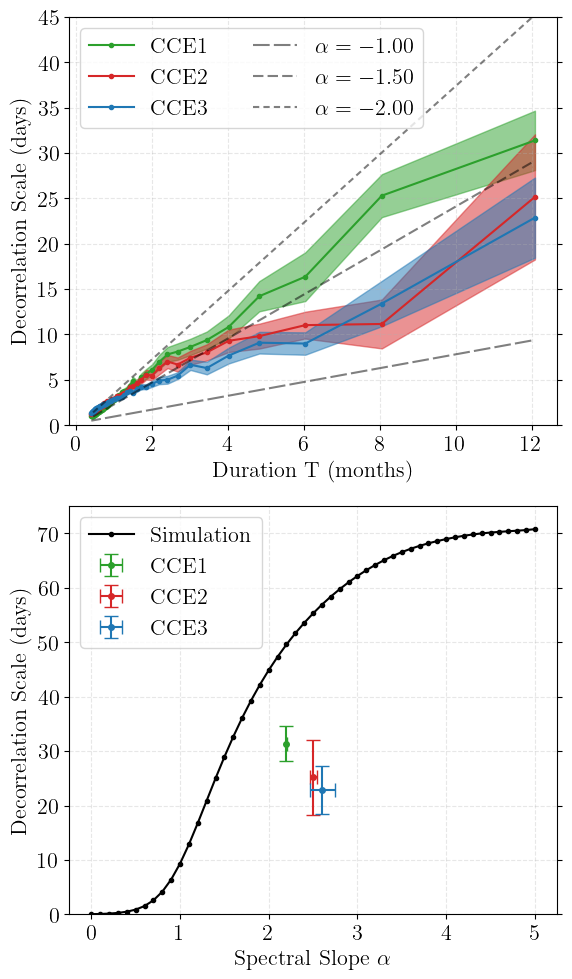

In [109]:
# Convert window sizes to units of months
scale_months = window_sizes_days / 30.44

# Find the scale closest to the 12 months 
duration = 12                            # Units: months
idx_scale  = np.argmin(abs(scale_months - duration))

# Create figure
fig, axes = plt.subplots(2,1,figsize=(6, 10))
ax_flat = axes.flatten()

##################
#-- Subplot 1 ---#
##################
ax = ax_flat[0]

# Plot potential density decor scales
ax.plot(scale_months, Lt_cce1_av_ensemble,'.-', color='tab:green',label='CCE1')
ax.plot(scale_months, Lt_cce2_av_ensemble,'.-', color='tab:red',label='CCE2')
ax.plot(scale_months, Lt_cce3_av_ensemble,'.-', color='tab:blue',label='CCE3')

# ax.plot(scale_months, Lt_cce1_av_50m,'.-', color='tab:green',label='CCE1')
# ax.plot(scale_months, Lt_cce2_av_50m,'.-', color='tab:red',label='CCE2')
# ax.plot(scale_months, Lt_cce3_av_50m,'.-', color='tab:blue',label='CCE3')

# Plot standard error of the mean
ax.fill_between(scale_months, Lt_cce1_av_ensemble - Lt_cce1_stdm_ensemble, Lt_cce1_av_ensemble + Lt_cce1_stdm_ensemble, color='tab:green', alpha=0.5)
ax.fill_between(scale_months, Lt_cce2_av_ensemble - Lt_cce2_stdm_ensemble, Lt_cce2_av_ensemble + Lt_cce2_stdm_ensemble, color='tab:red', alpha=0.5)
ax.fill_between(scale_months, Lt_cce3_av_ensemble - Lt_cce3_stdm_ensemble, Lt_cce3_av_ensemble + Lt_cce3_stdm_ensemble, color='tab:blue', alpha=0.5)

# ax.fill_between(scale_months, Lt_cce1_av_50m - Lt_cce1_stdm_50m, Lt_cce1_av_50m + Lt_cce1_stdm_50m, color='tab:green', alpha=0.5)
# ax.fill_between(scale_months, Lt_cce2_av_50m - Lt_cce2_stdm_50m, Lt_cce2_av_50m + Lt_cce2_stdm_50m, color='tab:red', alpha=0.5)
# ax.fill_between(scale_months, Lt_cce3_av_50m - Lt_cce3_stdm_50m, Lt_cce3_av_50m + Lt_cce3_stdm_50m, color='tab:blue', alpha=0.5)

# Plot the linear fit to the decorrelation scale vs. window size relation
ax.plot(scale_sim, Lt_fit_sim[10, :], linestyle=(0, (8, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[10]))
ax.plot(scale_sim, Lt_fit_sim[15, :], linestyle=(0, (5, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[15]))
ax.plot(scale_sim, Lt_fit_sim[20, :], linestyle=(0, (3, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[20]))

# Set axis attributes
ax.set_xlabel("Duration T (months)")
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_ylim(0,45)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3) 
ax.legend(ncol=2)

##################
#-- Subplot 2 ---#
##################
ax = ax_flat[1]

# Plot the decorrelation scale as a function of spectral slope for a 12 month duration 
ax.plot(alpha_sim, Lt_fit_sim[:,0], '.-', color='k', label = 'Simulation')

# Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
ax.errorbar(abs(S_depth_slope_sub[0]), Lt_cce1_av_ensemble[idx_scale], xerr=S_depth_slope_tot_unc[0], yerr=Lt_cce1_stdm_ensemble[idx_scale], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1')
ax.errorbar(abs(S_depth_slope_sub[1]), Lt_cce2_av_ensemble[idx_scale], xerr=S_depth_slope_sub_unc[1], yerr=Lt_cce2_stdm_ensemble[idx_scale],fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2')
ax.errorbar(abs(S_depth_slope_sub[2]), Lt_cce3_av_ensemble[idx_scale], xerr=S_depth_slope_sub_unc[2], yerr=Lt_cce3_stdm_ensemble[idx_scale],fmt='o', color='tab:blue', ms=4, capsize=5, label='CCE3')

# Set axis attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_ylim(0,75)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)
ax.legend()

# Show figure
plt.tight_layout()
plt.show()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_51974/853246782.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


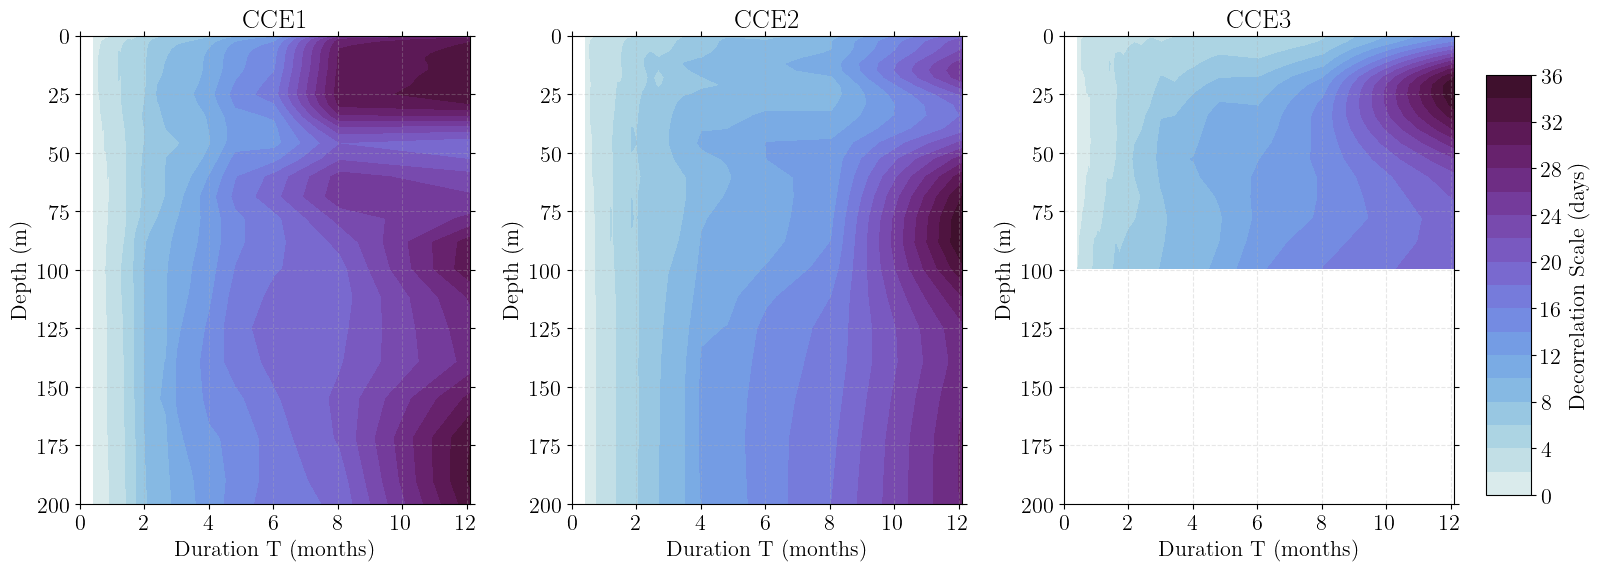

In [110]:
# Set plotting parameters
levels = np.arange(0,38,2)

# Create figure
fig, axes = plt.subplots(1,3,figsize=(15, 6))
ax_flat = axes.flatten()

#--- Subplot 1 ---# 
ax = ax_flat[0]

# Plot the decorrelation scale as a function of duration and depth 
pc = ax.contourf(scale_months, abs(depth_upper), Lt_cce1_av_days, levels=levels, cmap=cmo.dense)

# Set axis attributes
ax.set_xlabel("Duration T (months)")
ax.set_ylabel("Depth (m)")
ax.set_title("CCE1")
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_ylim(0,200)
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)

# Set colorbar
cax = fig.add_axes([1, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Decorrelation Scale (days)', fontsize=fontsize)

#--- Subplot 2 ---# 
ax = ax_flat[1]

# Plot the decorrelation scale as a function of duration and depth 
pc = ax.contourf(scale_months, abs(depth_upper), Lt_cce2_av_days, levels=levels, cmap=cmo.dense)

# Set axis attributes
ax.set_xlabel("Duration T (months)")
ax.set_ylabel("Depth (m)")
ax.set_title("CCE2")
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_ylim(0,200)
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)

#--- Subplot 2 ---# 
ax = ax_flat[2]

# Plot the decorrelation scale as a function of duration and depth 
pc = ax.contourf(scale_months, abs(depth_upper), Lt_cce3_av_days, levels=levels, cmap=cmo.dense)

# Set axis attributes
ax.set_xlabel("Duration T (months)")
ax.set_ylabel("Depth (m)")
ax.set_title("CCE3")
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_ylim(0,200)
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)

# Show figure
plt.tight_layout()
plt.show()

In [76]:
np.shape(S_seg_slope_sub)

(3, 29)

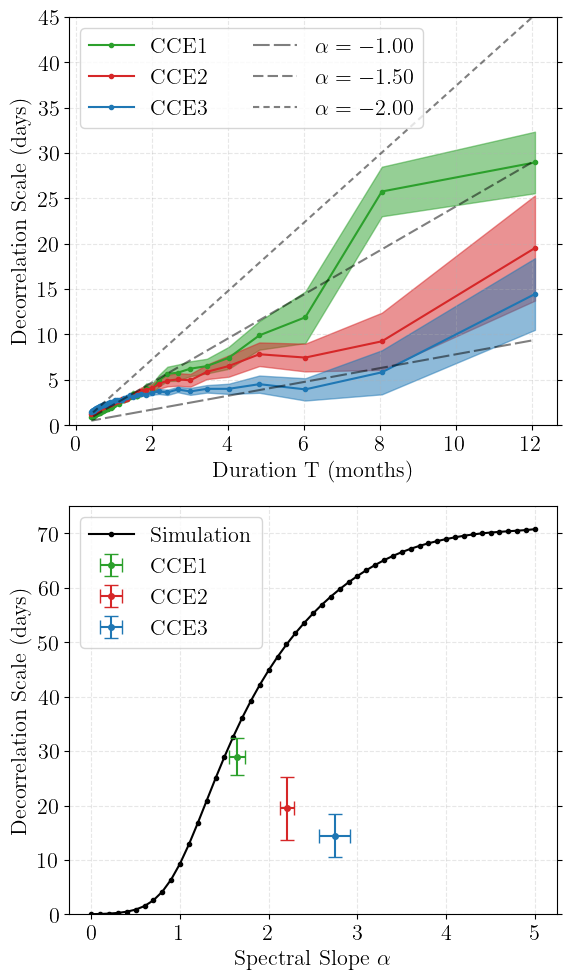

In [97]:
# Convert window sizes to units of months
scale_months = window_sizes_days / 30.44

# Find the depth closest to 10 meters
depth_target = 10                       # Units: meters
idx_depth   = np.argmin(abs(depth_upper - depth_target))

# Find the scale closest to the 12 months 
duration = 12                            # Units: months
idx_scale  = np.argmin(abs(scale_months - duration))
idx_scale_sim = np.argmin(abs(scale_sim - duration))

# Create figure
fig, axes = plt.subplots(2,1,figsize=(6, 10))
ax_flat = axes.flatten()

##################
#-- Subplot 1 ---#
##################
ax = ax_flat[0]

# Plot potential density decor scales
ax.plot(scale_months, Lt_cce1_av_days[idx_depth, :],'.-', color='tab:green',label='CCE1')
ax.plot(scale_months, Lt_cce2_av_days[idx_depth, :],'.-', color='tab:red',label='CCE2')
ax.plot(scale_months, Lt_cce3_av_days[idx_depth, :],'.-', color='tab:blue',label='CCE3')

# ax.plot(scale_months, Lt_cce1_av_50m,'.-', color='tab:green',label='CCE1')
# ax.plot(scale_months, Lt_cce2_av_50m,'.-', color='tab:red',label='CCE2')
# ax.plot(scale_months, Lt_cce3_av_50m,'.-', color='tab:blue',label='CCE3')

# Plot standard error of the mean
ax.fill_between(scale_months, Lt_cce1_av_days[idx_depth, :] - Lt_cce1_stdm_days[idx_depth, :], Lt_cce1_av_days[idx_depth, :] + Lt_cce1_stdm_days[idx_depth, :], color='tab:green', alpha=0.5)
ax.fill_between(scale_months, Lt_cce2_av_days[idx_depth, :] - Lt_cce2_stdm_days[idx_depth, :], Lt_cce2_av_days[idx_depth, :] + Lt_cce2_stdm_days[idx_depth, :], color='tab:red', alpha=0.5)
ax.fill_between(scale_months, Lt_cce3_av_days[idx_depth, :] - Lt_cce3_stdm_days[idx_depth, :], Lt_cce3_av_days[idx_depth, :] + Lt_cce3_stdm_days[idx_depth, :], color='tab:blue', alpha=0.5)

# ax.fill_between(scale_months, Lt_cce1_av_50m - Lt_cce1_stdm_50m, Lt_cce1_av_50m + Lt_cce1_stdm_50m, color='tab:green', alpha=0.5)
# ax.fill_between(scale_months, Lt_cce2_av_50m - Lt_cce2_stdm_50m, Lt_cce2_av_50m + Lt_cce2_stdm_50m, color='tab:red', alpha=0.5)
# ax.fill_between(scale_months, Lt_cce3_av_50m - Lt_cce3_stdm_50m, Lt_cce3_av_50m + Lt_cce3_stdm_50m, color='tab:blue', alpha=0.5)

# Plot the linear fit to the decorrelation scale vs. window size relation
ax.plot(scale_sim, Lt_fit_sim[10, :], linestyle=(0, (8, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[10]))
ax.plot(scale_sim, Lt_fit_sim[15, :], linestyle=(0, (5, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[15]))
ax.plot(scale_sim, Lt_fit_sim[20, :], linestyle=(0, (3, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[20]))

# Set axis attributes
ax.set_xlabel("Duration T (months)")
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_ylim(0,45)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3) 
ax.legend(ncol=2,loc='upper left')

##################
#-- Subplot 2 ---#
##################
ax = ax_flat[1]

# Plot the decorrelation scale as a function of spectral slope for a 12 month duration 
ax.plot(alpha_sim, Lt_fit_sim[:,0], '.-', color='k', label = 'Simulation')
# ax.plot(alpha_sim, Lt_av_sim[:,idx_scale_sim], '.-', color='k', label = 'Simulation')
# ax.fill_between(alpha_sim, Lt_av_sim[:,idx_scale_sim] - Lt_stdm_sim[:,idx_scale_sim], Lt_av_sim[:,idx_scale_sim] + Lt_stdm_sim[:,idx_scale_sim], color='k', alpha=0.3)

# Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
ax.errorbar(abs(S_seg_slope_sub[0,idx_depth]), Lt_cce1_av_days[idx_depth,idx_scale], xerr=S_seg_slope_sub_unc[0,idx_depth], yerr=Lt_cce1_stdm_days[idx_depth,idx_scale], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1')
ax.errorbar(abs(S_seg_slope_sub[1,idx_depth]), Lt_cce2_av_days[idx_depth,idx_scale], xerr=S_seg_slope_sub_unc[1,idx_depth], yerr=Lt_cce2_stdm_days[idx_depth,idx_scale],fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2')
ax.errorbar(abs(S_seg_slope_sub[2,idx_depth]), Lt_cce3_av_days[idx_depth,idx_scale], xerr=S_seg_slope_sub_unc[2,idx_depth], yerr=Lt_cce3_stdm_days[idx_depth,idx_scale],fmt='o', color='tab:blue', ms=4, capsize=5, label='CCE3')

# Set axis attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_ylim(0,75)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)
ax.legend(loc='upper left')

# Show figure
plt.tight_layout()
plt.show()

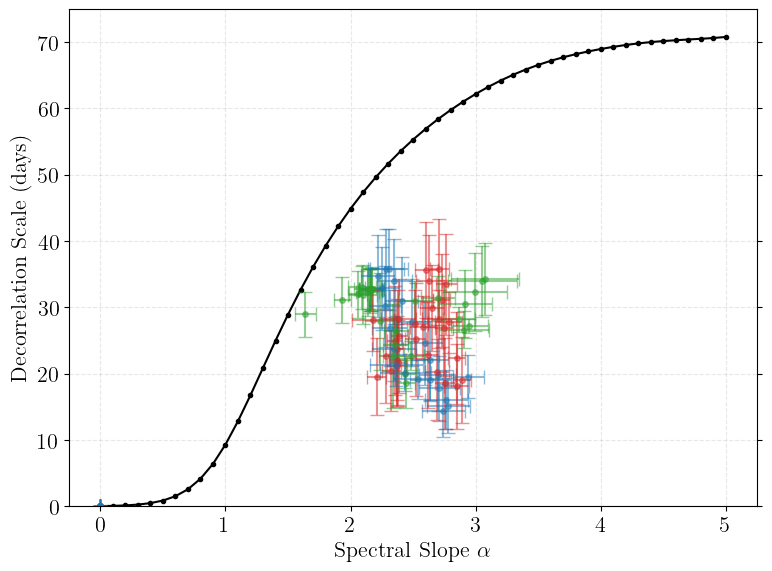

In [87]:
# Find the scale closest to the 12 months 
duration = 12                            # Units: months
idx_scale  = np.argmin(abs(scale_months - duration))

# Create figure
fig, ax = plt.subplots(1,1,figsize=(8, 6))

# Plot the decorrelation scale as a function of spectral slope for a 12 month duration 
ax.plot(alpha_sim, Lt_fit_sim[:,0], '.-', color='k', label = 'Simulation')

# Loop through depth 
for idepth in range(n_depth):

    # Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
    ax.errorbar(abs(S_seg_slope_sub[0,idepth]), Lt_cce1_av_days[idepth,idx_scale], xerr=S_seg_slope_sub_unc[0,idepth], yerr=Lt_cce1_stdm_days[idepth,idx_scale], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1', alpha=0.5)
    ax.errorbar(abs(S_seg_slope_sub[1,idepth]), Lt_cce2_av_days[idepth,idx_scale], xerr=S_seg_slope_sub_unc[1,idepth], yerr=Lt_cce2_stdm_days[idepth,idx_scale],fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2', alpha=0.5)
    ax.errorbar(abs(S_seg_slope_sub[2,idepth]), Lt_cce3_av_days[idepth,idx_scale], xerr=S_seg_slope_sub_unc[2,idepth], yerr=Lt_cce3_stdm_days[idepth,idx_scale],fmt='o', color='tab:blue', ms=4, capsize=5, label='CCE3', alpha=0.5)

    # ax.errorbar(abs(S_seg_slope_tot[0,idepth]), Lt_cce1_av_days[idepth,idx_scale], xerr=S_seg_slope_tot_unc[0,idepth], yerr=Lt_cce1_stdm_days[idepth,idx_scale], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1', alpha=0.5)
    # ax.errorbar(abs(S_seg_slope_tot[1,idepth]), Lt_cce2_av_days[idepth,idx_scale], xerr=S_seg_slope_tot_unc[1,idepth], yerr=Lt_cce2_stdm_days[idepth,idx_scale],fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2', alpha=0.5)
    # ax.errorbar(abs(S_seg_slope_tot[2,idepth]), Lt_cce3_av_days[idepth,idx_scale], xerr=S_seg_slope_tot_unc[2,idepth], yerr=Lt_cce3_stdm_days[idepth,idx_scale],fmt='o', color='tab:blue', ms=4, capsize=5, label='CCE3', alpha=0.5)


# Set axis attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_ylim(0,75)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)
#ax.legend(loc='upper left')

# Show figure
plt.tight_layout()
plt.show()

In [8]:
np.shape(data)

(3, 17661, 90)

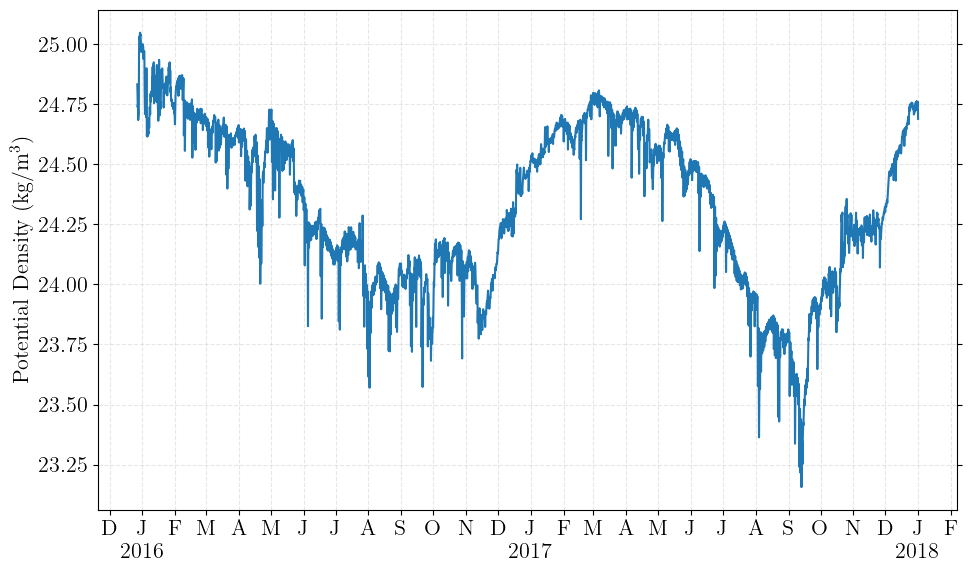

In [17]:
# Initialize site and depth indices
isite = 0
idepth = 0

# Create figure and axis
fig, ax = plt.subplots(1,1,figsize=(10, 6))

# Plot a sample time series at a single site and depth
ax.plot(time_dt, data[isite,:,idepth], lw=1.5, ls='-', color='tab:blue')

# Set figure attributes
ax.set_ylabel('Potential Density (kg/m$^3$)')
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))

# Show figure
plt.tight_layout()
plt.show()

Plot the power spectrum at the same site and depth

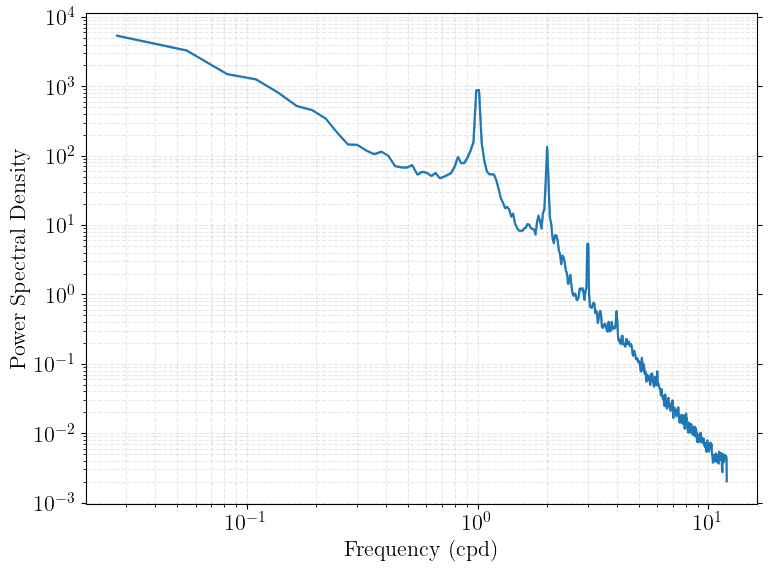

In [24]:
# Create figure and axis
fig, ax = plt.subplots(1,1,figsize=(8, 6))

# Plot the power spectrum at a single site and depth
ax.loglog(f_cpd_seg[1:], S_seg[isite,idepth,1:], lw=1.5, ls='-', color='tab:blue')  
ax.fill_between(f_cpd_seg[1:], CI_seg[isite,idepth,1:,0], CI_seg[isite,idepth,1:,1], color='tab:blue', alpha=0.5)

# Set figure attributes
ax.set_xlabel('Frequency (cpd)')
ax.set_ylabel('Power Spectral Density')
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, which='both', ls='--', alpha=0.3) 

# Show figure
plt.tight_layout()
plt.show()

In [27]:
np.shape(Lt_av_sim)

(51, 57)

In [28]:
np.shape(alpha_sim)

(51,)

In [29]:
np.shape(scale_sim)

(57,)

python(14165) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14166) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14167) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14168) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14169) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14170) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14171) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14172) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


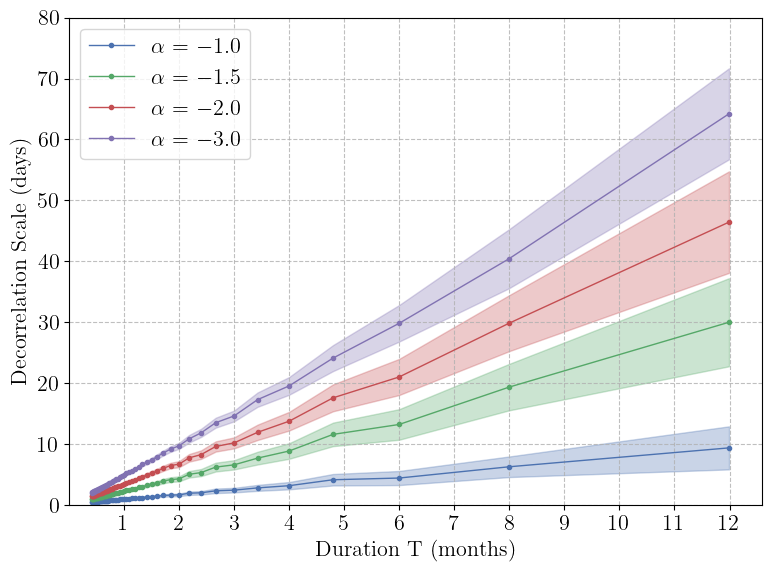

In [52]:
# Set plotting parameters
cn = 0
colors_decor = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']
scale_sim_rev = scale_sim[::-1]
Lt_av_sim_rev = Lt_av_sim[:, ::-1]
Lt_stdm_sim_rev = Lt_stdm_sim[:, ::-1]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through spectral slopes
for i, alpha in enumerate(alpha_sim):
    
    # Plot just spectral slopes of 1, 1.5, 2, and 3
    if (alpha == 1) | (alpha == 1.5) | (alpha == 2) | (alpha == 3): 

        # Plot mean decorrelation scale
        ax.plot(scale_sim_rev, Lt_av_sim_rev[i, :], '.-', color=colors_decor[cn],
                linewidth=1, label=r'$\alpha$ = $-${:.1f}'.format(alpha))
        
        # Plot standard error as shaded region
        ax.fill_between(scale_sim_rev,
                        Lt_av_sim_rev[i, :] - Lt_stdm_sim_rev[i, :],
                        Lt_av_sim_rev[i, :] + Lt_stdm_sim_rev[i, :],
                        color=colors_decor[cn], alpha=0.3)

        # Reset counter 
        cn += 1

# Set figure attributes
ax.set_xlabel('Duration T (months)')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xlim(0, np.max(scale_sim) * 1.05)
ax.set_xticks(np.arange(1,13))
ax.set_ylim(0,80)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='upper left', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

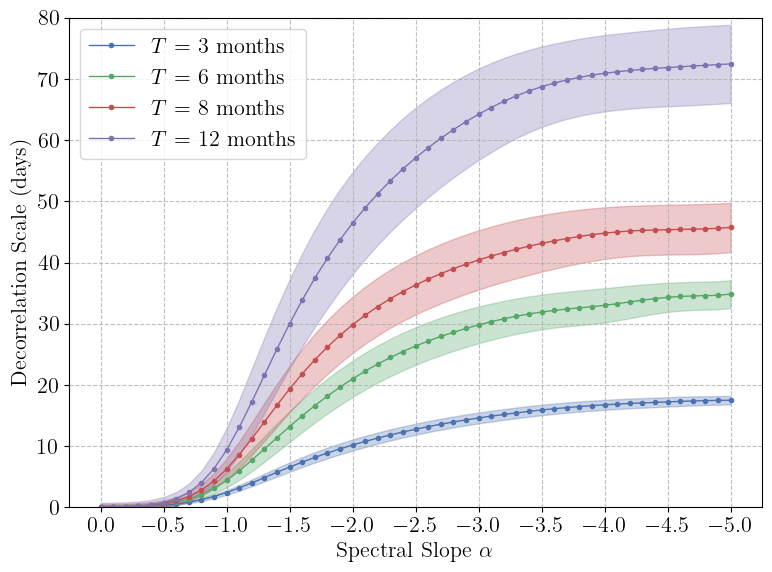

In [54]:
# Set plotting parameters
cn = 0

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through spectral slopes
for i, scale in enumerate(scale_sim_rev):
    
    # Plot durations of 3, 6, 8, and 12 months
    if (np.round(scale,1) == 3.0) | (np.round(scale,1) == 6.0) | (np.round(scale,1) == 8.0) | (np.round(scale,1) == 12.0): 

        # Plot mean decorrelation scale
        ax.plot(-1*alpha_sim, Lt_av_sim_rev[:, i], '.-', color=colors_decor[cn],
                linewidth=1, label=r'$T$ = {:.0f} months'.format(scale))
        
        # Plot standard error as shaded region
        ax.fill_between(-1*alpha_sim,
                        Lt_av_sim_rev[:, i] - Lt_stdm_sim_rev[:, i],
                        Lt_av_sim_rev[:, i] + Lt_stdm_sim_rev[:, i],
                        color=colors_decor[cn], alpha=0.3)

        # Reset counter 
        cn += 1

# Set figure attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks(np.arange(-5,0+0.5,0.5))
ax.set_ylim(0,80)
ax.invert_xaxis()
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='upper left', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

In [39]:
i

0

In [40]:
np.shape(Lt_av_sim)

(51, 57)